# Import all necessary libraries

In [6]:
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Set up matplotlib for better visualization

In [7]:

import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 10)

# Download necessary NLTK resources with error handling

In [8]:

try:
    # Create a directory for NLTK data
    import os
    nltk_data_dir = os.path.join(os.getcwd(), 'nltk_data')
    os.makedirs(nltk_data_dir, exist_ok=True)
    
    # Download resources to the specified directory
    nltk.download('punkt', download_dir=nltk_data_dir)
    nltk.download('stopwords', download_dir=nltk_data_dir)
    nltk.download('wordnet', download_dir=nltk_data_dir)
    nltk.download('averaged_perceptron_tagger', download_dir=nltk_data_dir)
    nltk.download('omw-1.4', download_dir=nltk_data_dir)
    
    # Add the directory to NLTK's search path
    nltk.data.path.append(nltk_data_dir)
    print("NLTK resources downloaded successfully")
except Exception as e:
    print(f"Error downloading NLTK resources: {e}")
    print("Continuing with limited functionality")

NLTK resources downloaded successfully


[nltk_data] Downloading package punkt to C:\Data\Indolike
[nltk_data]     projects\spam SMS detection\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Data\Indolike
[nltk_data]     projects\spam SMS detection\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Data\Indolike
[nltk_data]     projects\spam SMS detection\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Data\Indolike projects\spam SMS
[nltk_data]     detection\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to C:\Data\Indolike
[nltk_data]     projects\spam SMS detection\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Load data

In [9]:

df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

In [10]:
# Display basic information about the dataset
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
# Check class distribution
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


# Visualize class distribution

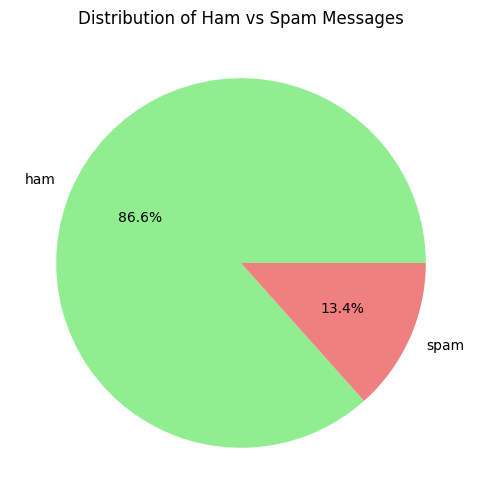

In [12]:

plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
plt.title('Distribution of Ham vs Spam Messages')
plt.ylabel('')
plt.show()

In [13]:
# Analyze text length
df['text_length'] = df['text'].apply(len)

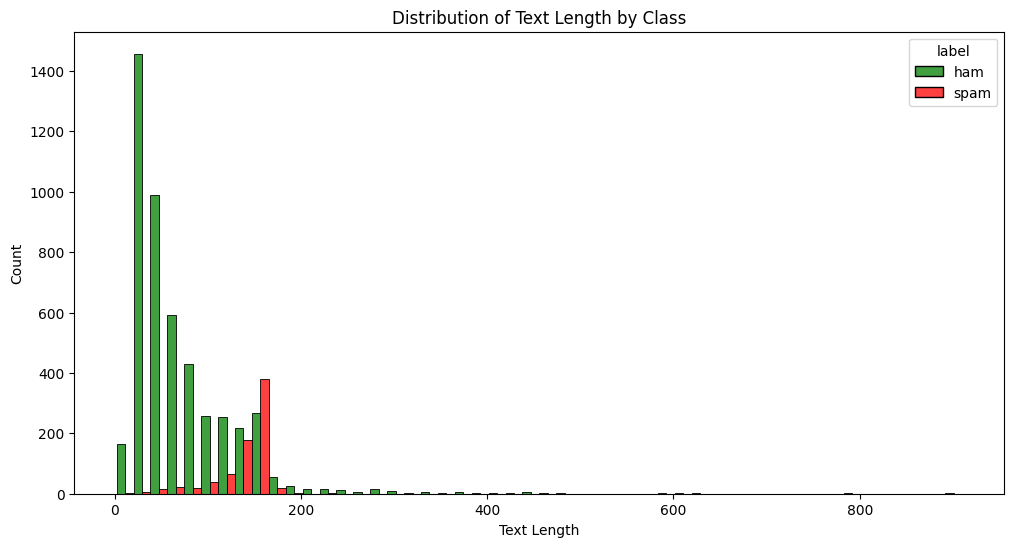

In [14]:
# Plot text length distribution by class
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='text_length', hue='label', bins=50, multiple='dodge', palette=['green', 'red'])
plt.title('Distribution of Text Length by Class')
plt.xlabel('Text Length')
plt.show()

# Create word clouds for each class

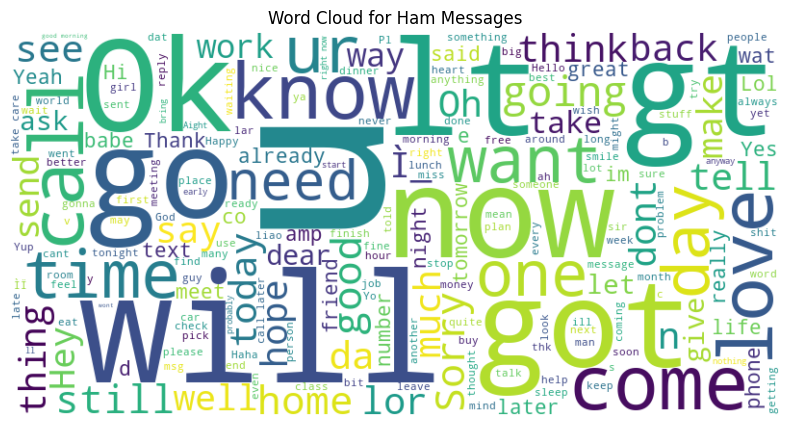

In [16]:
# For ham messages
ham_text = ' '.join(df[df['label'] == 'ham']['text'])
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Ham Messages')
plt.axis('off')
plt.show()

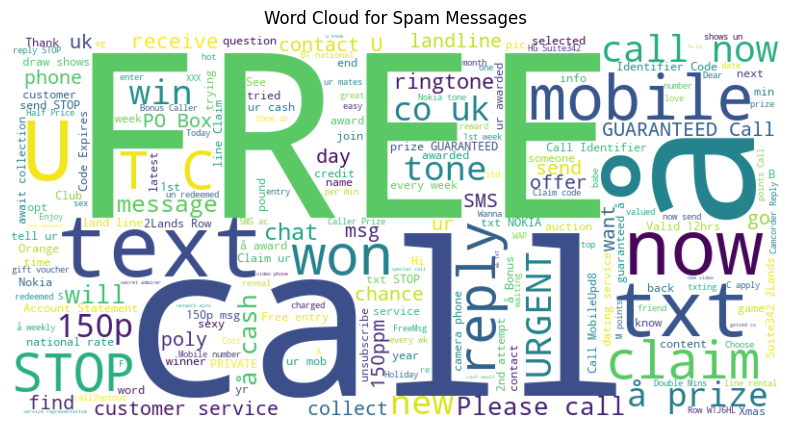

In [17]:
# For spam messages
spam_text = ' '.join(df[df['label'] == 'spam']['text'])
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Spam Messages')
plt.axis('off')
plt.show()

# Text preprocessing function

In [18]:

def preprocess_text(text):
    try:
        # Convert to lowercase
        text = text.lower()
        
        # Remove punctuation
        text = ''.join([char for char in text if char not in string.punctuation])
        
        # Tokenize (with fallback)
        try:
            tokens = word_tokenize(text)
        except:
            tokens = text.split()
        
        # Remove stopwords (with fallback)
        try:
            stop_words = set(stopwords.words('english'))
            tokens = [word for word in tokens if word not in stop_words]
        except:
            pass  # Continue without removing stopwords if there's an error
        
        # Lemmatization (with fallback)
        try:
            lemmatizer = WordNetLemmatizer()
            tokens = [lemmatizer.lemmatize(word) for word in tokens]
        except:
            pass  # Continue without lemmatization if there's an error
        
        return ' '.join(tokens)
    except Exception as e:
        print(f"Error in preprocessing: {e}")
        return text  # Return original text if preprocessing fails

In [19]:
# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

# Feature Engineering

In [20]:

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['processed_text'])

In [21]:
# Count Vectorizer (alternative)
count_vec = CountVectorizer(max_features=5000)
X_count = count_vec.fit_transform(df['processed_text'])

In [22]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['label'])  # 0 for ham, 1 for spam

In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Model Building and Evaluation

### 1. Naive Bayes

In [24]:

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.77      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

Confusion Matrix:
 [[965   1]
 [ 35 114]]
Accuracy: 0.967713004484305


### 2. Random Forest

In [25]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115

Confusion Matrix:
 [[965   1]
 [ 27 122]]
Accuracy: 0.9748878923766816


### 3. Logistic Regression

In [26]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       966
           1       0.99      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.97      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115

Confusion Matrix:
 [[965   1]
 [ 47 102]]
Accuracy: 0.95695067264574


### 4. SVM

In [27]:

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.97      1115
weighted avg       0.99      0.98      0.98      1115

Confusion Matrix:
 [[966   0]
 [ 17 132]]
Accuracy: 0.9847533632286996


# Model Comparison

In [28]:

models = {
    'Naive Bayes': nb,
    'Random Forest': rf,
    'Logistic Regression': lr,
    'SVM': svm
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    accuracy = accuracy_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.967713   0.991304  0.765101  0.863636
1        Random Forest  0.974888   0.991870  0.818792  0.897059
2  Logistic Regression  0.956951   0.990291  0.684564  0.809524
3                  SVM  0.984753   1.000000  0.885906  0.939502


# Visualize model performance

C:\Users\User\AppData\Local\Temp\ipykernel_26212\4044197234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


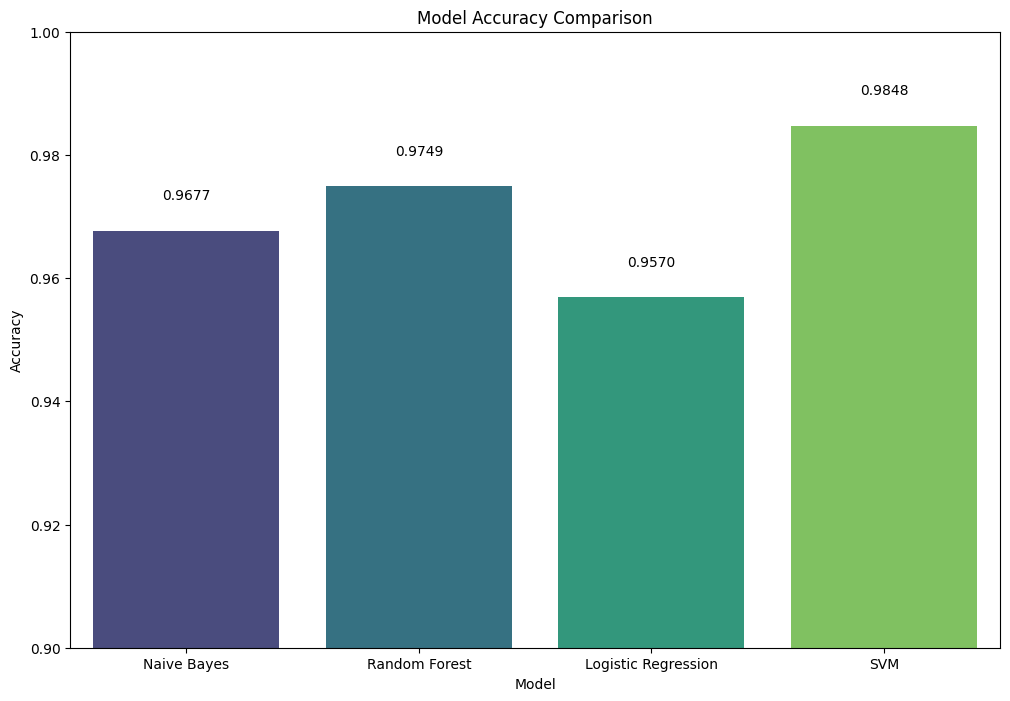

In [29]:

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.9, 1.0)  # Adjust as needed based on actual results
for i, v in enumerate(results_df['Accuracy']):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()

# Hyperparameter Tuning for the best model

In [31]:

param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test)
print(classification_report(y_test, y_pred_best))

C:\Data\Indolike projects\spam SMS detection\env\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Data\Indolike projects\spam SMS detection\env\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.9159292231393706
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



# Feature Importance Analysis

In [32]:

feature_names = tfidf.get_feature_names_out()
coefs = best_lr.coef_[0]
top_features = pd.DataFrame({'feature': feature_names, 'coef': coefs})
top_features = top_features.sort_values('coef', ascending=False)

print("Top 10 spam indicators:")
print(top_features.head(10))

print("\nTop 10 ham indicators:")
print(top_features.tail(10))

Top 10 spam indicators:
          feature       coef
4631          txt  12.195862
955         claim  10.980555
4095      service  10.945210
3366       mobile   9.347625
3778        prize   8.836048
2471  information   8.413390
4329         stop   8.285362
3932        reply   8.198647
4474         text   8.025401
373         88066   7.918583

Top 10 ham indicators:
      feature      coef
3392  morning -3.833915
2170      hey -4.020883
1920      got -4.049244
3553       ok -4.080576
4033      say -4.262031
4174      sir -5.054283
2405      ill -5.348576
2997    liked -5.456895
4980      yup -6.026265
3144     ltgt -7.170250


C:\Users\User\AppData\Local\Temp\ipykernel_26212\1604846439.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=top_features.head(top_n), palette='Reds_r')
C:\Users\User\AppData\Local\Temp\ipykernel_26212\1604846439.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=top_features.tail(top_n).sort_values('coef'), palette='Greens_r')


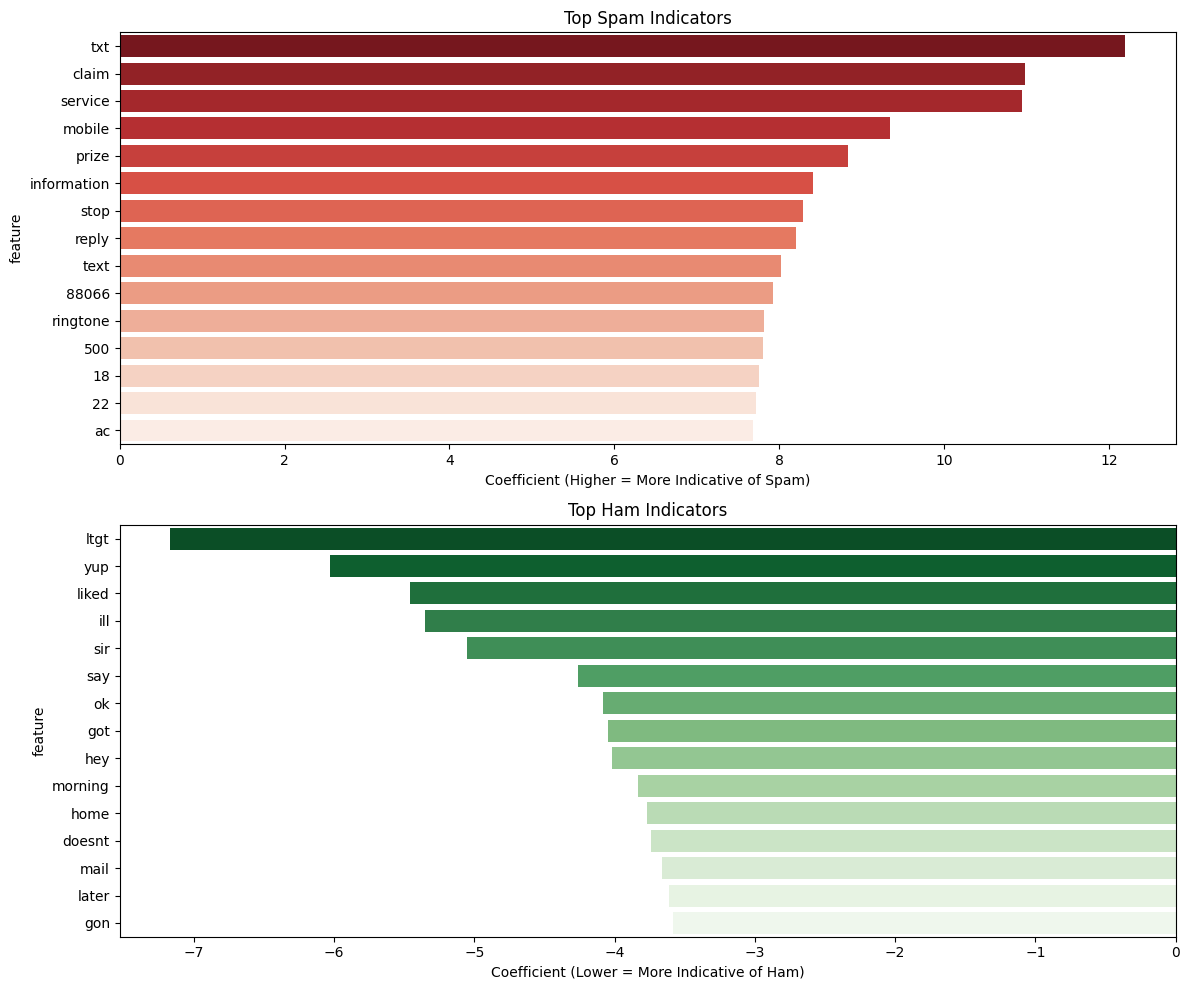

In [39]:
# Define the number of features to display
top_n = 15  # or any other number you prefer

plt.figure(figsize=(12, 10))

# Top spam features
plt.subplot(2, 1, 1)
sns.barplot(x='coef', y='feature', data=top_features.head(top_n), palette='Reds_r')
plt.title('Top Spam Indicators')
plt.xlabel('Coefficient (Higher = More Indicative of Spam)')

# Top ham features 
plt.subplot(2, 1, 2)
sns.barplot(x='coef', y='feature', data=top_features.tail(top_n).sort_values('coef'), palette='Greens_r')
plt.title('Top Ham Indicators')
plt.xlabel('Coefficient (Lower = More Indicative of Ham)')

plt.tight_layout()
plt.show()


# Final Model Deployment

In [34]:

# Save the model and vectorizer
joblib.dump(best_lr, 'spam_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

# Example 

In [40]:

def predict_spam(text, model_path='spam_classifier.pkl', vectorizer_path='tfidf_vectorizer.pkl'):
    try:
        model = joblib.load(model_path)
        vectorizer = joblib.load(vectorizer_path)
        
        # Process the text the same way we did for training
        processed_text = preprocess_text(text)
        text_vector = vectorizer.transform([processed_text])
        prediction = model.predict(text_vector)
        
        # Get prediction probability
        proba = model.predict_proba(text_vector)[0]
        confidence = proba[1] if prediction[0] == 1 else proba[0]
        
        return {
            'class': 'spam' if prediction[0] == 1 else 'ham',
            'confidence': confidence,
            'processed_text': processed_text
        }
    except Exception as e:
        return {'error': str(e)}

In [41]:

test_messages = [
    "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",
    "WINNER!! As a valued network customer you have been selected to receive a £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.",
    "Hi, how are you doing today?",
    "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18"
]

for i, msg in enumerate(test_messages):
    result = predict_spam(msg)
    print(f"Message {i+1}: {msg[:50]}...")
    print(f"Prediction: {result['class']}")
    if 'confidence' in result:
        print(f"Confidence: {result['confidence']:.4f}")
    print("---")

Message 1: Go until jurong point, crazy.. Available only in b...
Prediction: ham
Confidence: 0.9985
---
Message 2: WINNER!! As a valued network customer you have bee...
Prediction: spam
Confidence: 0.9992
---
Message 3: Hi, how are you doing today?...
Prediction: ham
Confidence: 0.9982
---
Message 4: URGENT! You have won a 1 week FREE membership in o...
Prediction: spam
Confidence: 0.9967
---


# Final visualization: Confusion matrix heatmap for best model

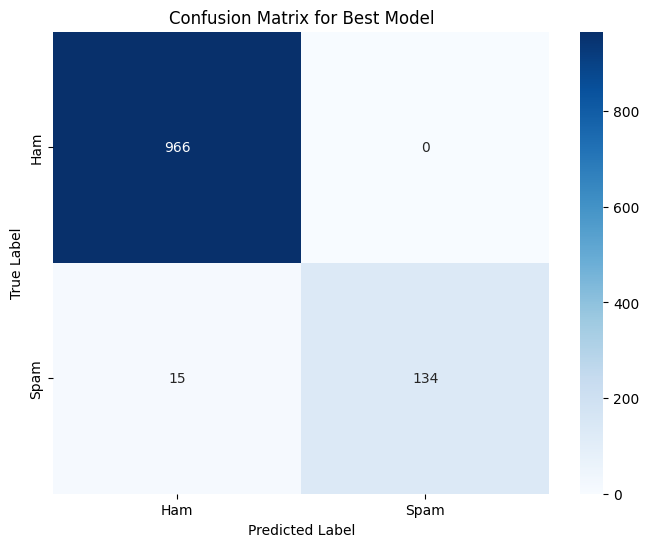

In [42]:

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix for Best Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()